Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

In [141]:
pip install uproot

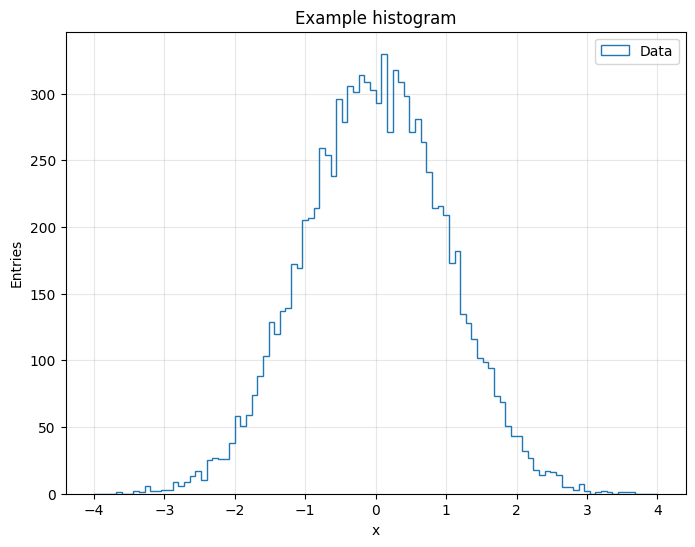

In [142]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt

# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generate random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [143]:
!pip install uproot

In [144]:
!mkdir LHCb_Data && cd LHCb_Data && wget http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root

mkdir: cannot create directory ‘LHCb_Data’: File exists


In [145]:
import uproot

# Open the ROOT file
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

px

array([  375.2842054 , -4985.13078543, -1265.45654435, ...,
        2606.91083928,  -294.71098895,   499.04234923])

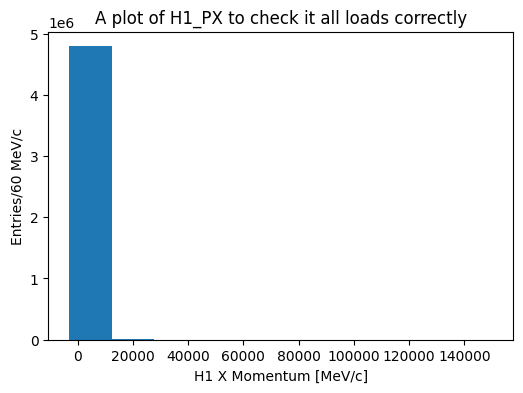

In [146]:
# now our data is an array - we can plot it :)

plt.figure(figsize=(6, 4))


#play with the variables below ...
plt.hist(
    px,
    bins=10,
    range=(-3000, 150000),
    histtype="bar"
)

#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("A plot of H1_PX to check it all loads correctly")

plt.show()

This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1451410097.py:44: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
/tmp/ipython-input-1451410097.py:44: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"


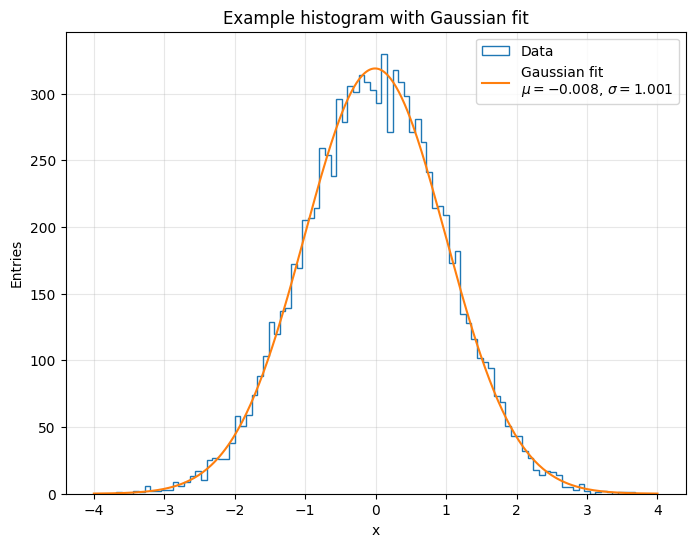

In [147]:
# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# abels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot (equivalent to c.Draw())
plt.show()

## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

#Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [148]:
#Using Uproot, load your data file and load the variables you think are useful for this analysis - I recommend learning what your data structure is...so plotting and calculations becomes easier later.

In [149]:
tree.keys() #checking what is in the files


['B_FlightDistance',
 'B_VertexChi2',
 'H1_PX',
 'H1_PY',
 'H1_PZ',
 'H1_ProbK',
 'H1_ProbPi',
 'H1_Charge',
 'H1_IPChi2',
 'H1_isMuon',
 'H2_PX',
 'H2_PY',
 'H2_PZ',
 'H2_ProbK',
 'H2_ProbPi',
 'H2_Charge',
 'H2_IPChi2',
 'H2_isMuon',
 'H3_PX',
 'H3_PY',
 'H3_PZ',
 'H3_ProbK',
 'H3_ProbPi',
 'H3_Charge',
 'H3_IPChi2',
 'H3_isMuon']

[-1  1]


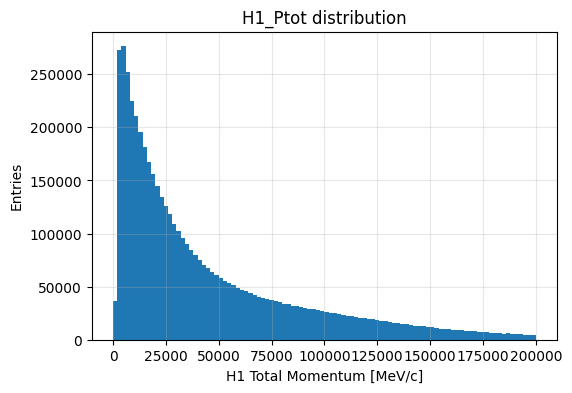

In [150]:
# making shortcuts for daughter momenta
H1_PX = tree["H1_PX"].array(library="np")  # X component of H1 momentum
H1_PY = tree["H1_PY"].array(library="np")  # Y component
H1_PZ = tree["H1_PZ"].array(library="np")  # Z component

H2_PX = tree["H2_PX"].array(library="np")  # same for H2
H2_PY = tree["H2_PY"].array(library="np")
H2_PZ = tree["H2_PZ"].array(library="np")

H3_PX = tree["H3_PX"].array(library="np")  # same for H3
H3_PY = tree["H3_PY"].array(library="np")
H3_PZ = tree["H3_PZ"].array(library="np")


# making shortcuts for the charges
H1_Charge = tree["H1_Charge"].array(library="np")
H2_Charge = tree["H2_Charge"].array(library="np")
H3_Charge = tree["H3_Charge"].array(library="np")

# making the Bcharge
B_Charge = H1_Charge + H2_Charge + H3_Charge  # sum of daughter charges to get total B charge

# to check if it worked
print(np.unique(B_Charge))  # expected: -1, +1 only


# calculating total momentum for each daughter
H1_Ptot = np.sqrt(H1_PX**2 + H1_PY**2 + H1_PZ**2)  # Ptot = sqrt(Px^2+Py^2+Pz^2)
H2_Ptot = np.sqrt(H2_PX**2 + H2_PY**2 + H2_PZ**2)
H3_Ptot = np.sqrt(H3_PX**2 + H3_PY**2 + H3_PZ**2)


# quick plot to check H1 momentum distribution
plt.figure(figsize=(6,4))
plt.hist(H1_Ptot, bins=100, range=(0, 200000))  # range chosen to cover expected momenta
plt.xlabel("H1 Total Momentum [MeV/c]")
plt.ylabel("Entries")
plt.title("H1_Ptot distribution")
plt.grid(alpha=0.3)
plt.show()

In [151]:
#Here make a plot of the Total momentum of each of the three daughters on one plot

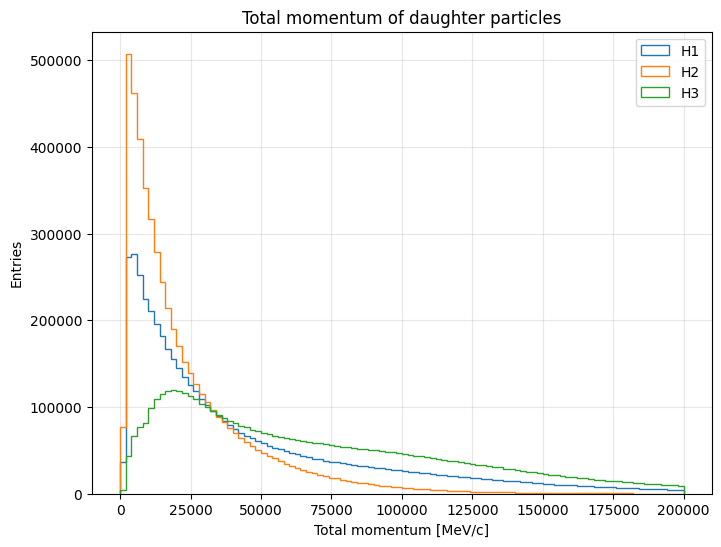

In [152]:
plt.figure(figsize=(8, 6))  # make pretty plot with all 3 H

bins = 100
pmin, pmax = 0, 200000  # MeV/c, chosen to cover expected momenta for all daughters

# plot H1 momentum
plt.hist(H1_Ptot, bins=bins, range=(pmin, pmax), histtype="step", label="H1")  # step style for clarity

# plot H2 momentum
plt.hist(H2_Ptot, bins=bins, range=(pmin, pmax), histtype="step", label="H2")  # same style for comparison

# plot H3 momentum
plt.hist(H3_Ptot, bins=bins, range=(pmin, pmax), histtype="step", label="H3")  # same style for comparison

plt.xlabel("Total momentum [MeV/c]")
plt.ylabel("Entries")
plt.title("Total momentum of daughter particles")
plt.legend()
plt.grid(alpha=0.3)  # add light grid for readability

plt.show()

Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

In [153]:
#use the histogram plotting tools, plot the momentum of the mother

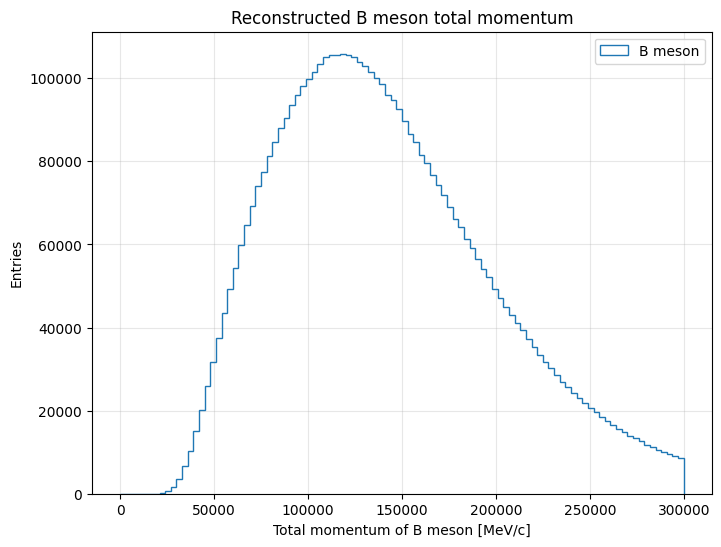

In [154]:
# make B momentum components by summing daughters
B_PX = H1_PX + H2_PX + H3_PX  # X component of B
B_PY = H1_PY + H2_PY + H3_PY  # Y component
B_PZ = H1_PZ + H2_PZ + H3_PZ  # Z component

# calculate total momentum of B meson
B_Ptot = np.sqrt(B_PX**2 + B_PY**2 + B_PZ**2)  # Ptot = sqrt(Px^2 + Py^2 + Pz^2)

# plot of B meson momentum
plt.figure(figsize=(8, 6))  # larger figure for clarity

plt.hist(B_Ptot, bins=100, range=(0, 300000), histtype="step", label="B meson")  # step style again

plt.xlabel("Total momentum of B meson [MeV/c]")
plt.ylabel("Entries")
plt.title("Reconstructed B meson total momentum")
plt.legend()
plt.grid(alpha=0.3)

plt.show()



Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [155]:
# print the 45th entry from your array(s) together with the variable name, maybe in a nice list or table.

In [156]:
i = 44  # 45th entry

print(f"Event {i+1}")
print("-----------------------------")
print(f"H1_PX: {H1_PX[i]:.1f}  MeV/c")
print(f"H1_PY: {H1_PY[i]:.1f}  MeV/c")
print(f"H1_PZ: {H1_PZ[i]:.1f}  MeV/c")
print()
print(f"H2_PX: {H2_PX[i]:.1f}  MeV/c")
print(f"H2_PY: {H2_PY[i]:.1f}  MeV/c")
print(f"H2_PZ: {H2_PZ[i]:.1f}  MeV/c")
print()
print(f"H3_PX: {H3_PX[i]:.1f}  MeV/c")
print(f"H3_PY: {H3_PY[i]:.1f}  MeV/c")
print(f"H3_PZ: {H3_PZ[i]:.1f}  MeV/c")
print()
print(f"B_PX:  {B_PX[i]:.1f}  MeV/c")
print(f"B_PY:  {B_PY[i]:.1f}  MeV/c")
print(f"B_PZ:  {B_PZ[i]:.1f}  MeV/c")
print(f"B_Ptot:{B_Ptot[i]:.1f}  MeV/c")


Event 45
-----------------------------
H1_PX: -1634.8  MeV/c
H1_PY: 838.7  MeV/c
H1_PZ: 15416.9  MeV/c

H2_PX: -3456.2  MeV/c
H2_PY: -328.8  MeV/c
H2_PZ: 21752.8  MeV/c

H3_PX: -2892.8  MeV/c
H3_PY: -2105.7  MeV/c
H3_PZ: 52930.5  MeV/c

B_PX:  -7983.8  MeV/c
B_PY:  -1595.8  MeV/c
B_PZ:  90100.1  MeV/c
B_Ptot:90467.2  MeV/c


We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

In [157]:
#First find the energy (you might have to do some physics thinking here)

# The using the total momentum find the reconstructed mass of the B

# Now write your new variables to an array

#Now plot a histogram of the range of masses of the B meson.

#Does this match what we would expect from theory?

#What are the features of your plot that you see?

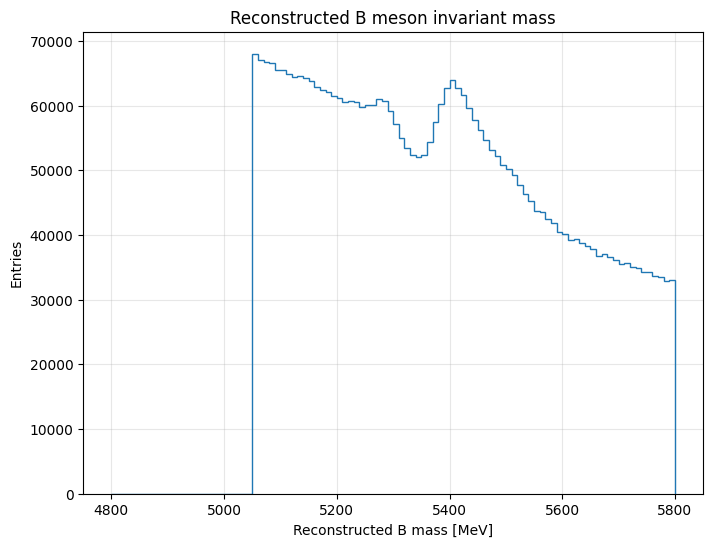

In [158]:
# compute energies of daughters using E^2 = p^2 + m^2
mK = 493.677  # MeV, mass of daughter Kaon

E1 = np.sqrt(H1_Ptot**2 + mK**2)  # energy of H1
E2 = np.sqrt(H2_Ptot**2 + mK**2)  #H2
E3 = np.sqrt(H3_Ptot**2 + mK**2)  #H3

# total energy of B meson
B_E = E1 + E2 + E3  # energy conservation

# calculate B meson invariant mass using m^2 = E^2 - p^2
B_M2 = B_E**2 - B_Ptot**2  # squared mass
B_M = np.sqrt(B_M2)  # B mass per event

# B_M is one value per event (experimental mass measured in detector)

# plot B meson invariant mass
plt.figure(figsize=(8, 6))

plt.hist(B_M, bins=100, range=(4800, 5800), histtype="step")

plt.xlabel("Reconstructed B mass [MeV]")
plt.ylabel("Entries")
plt.title("Reconstructed B meson invariant mass")
plt.grid(alpha=0.3)

plt.show()

# PDG B meson mass reference: 5279 MeV

We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

In [159]:
#Make plots of H1/H2/H3 _ProbK on one plot


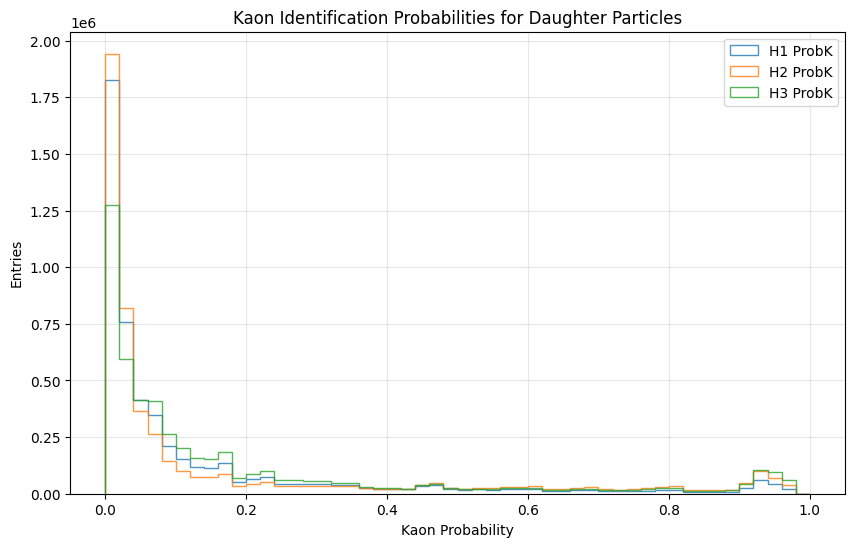

In [160]:
# load probability variables for particle ID
H1_ProbK = tree["H1_ProbK"].array(library="np")  # Kaon probability H1
H2_ProbK = tree["H2_ProbK"].array(library="np")  # H2
H3_ProbK = tree["H3_ProbK"].array(library="np")  # H3

H1_ProbPi = tree["H1_ProbPi"].array(library="np")  # Pion probability H1
H2_ProbPi = tree["H2_ProbPi"].array(library="np")  # H2
H3_ProbPi = tree["H3_ProbPi"].array(library="np")  # H3


# plot Kaon probabilities for all daughters
plt.figure(figsize=(10, 6))

bins = 50
prob_min, prob_max = 0, 1  # probabilities between 0 and 1

plt.hist(H1_ProbK, bins=bins, range=(prob_min, prob_max), histtype="step", label="H1 ProbK", alpha=0.8)
plt.hist(H2_ProbK, bins=bins, range=(prob_min, prob_max), histtype="step", label="H2 ProbK", alpha=0.8)
plt.hist(H3_ProbK, bins=bins, range=(prob_min, prob_max), histtype="step", label="H3 ProbK", alpha=0.8)

plt.xlabel("Kaon Probability")
plt.ylabel("Entries")
plt.title("Kaon Identification Probabilities for Daughter Particles")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [161]:
# Do the same for the Probability of being a Pion. Do these distributions match expectations?

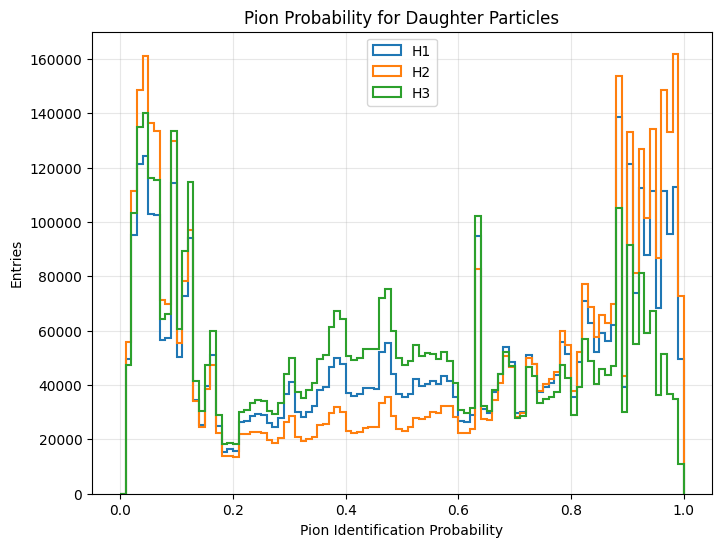

In [162]:
# load probability variables for particle ID
H1_ProbPi = tree["H1_ProbPi"].array(library="np")  # Pion probabilities
H2_ProbPi = tree["H2_ProbPi"].array(library="np")
H3_ProbPi = tree["H3_ProbPi"].array(library="np")

# plot Pion probabilities for all daughters
plt.figure(figsize=(8, 6))

bins = 100
prob_min, prob_max = 0, 1  # probabilities between 0 and 1

plt.hist(H1_ProbPi, bins=bins, range=(prob_min, prob_max), histtype="step", linewidth=1.5, label="H1")  # plots
plt.hist(H2_ProbPi, bins=bins, range=(prob_min, prob_max), histtype="step", linewidth=1.5, label="H2")
plt.hist(H3_ProbPi, bins=bins, range=(prob_min, prob_max), histtype="step", linewidth=1.5, label="H3")

plt.xlabel("Pion Identification Probability")
plt.ylabel("Entries")
plt.title("Pion Probability for Daughter Particles")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [163]:
# okay, the Kaon and Pion probability graphs make sense because the distributions peak near 0 and 1 as expected,
# showing that most tracks are clearly identified as either Kaons or Pions

In [164]:
#The pion probability distributions show significant population at high probability values, consistent with the kaon probability
#distributions peaking near zero. This indicates that many tracks in the raw dataset are more pion-like than kaon-like,
#as expected before applying particle identification cuts.

In [165]:
#For all our particles, make a plot of the B_VertexChi2

#Feeling ambitious? Maybe make a 2d plot of Kaon and Pion Prob in a 2 dimensional analysis?


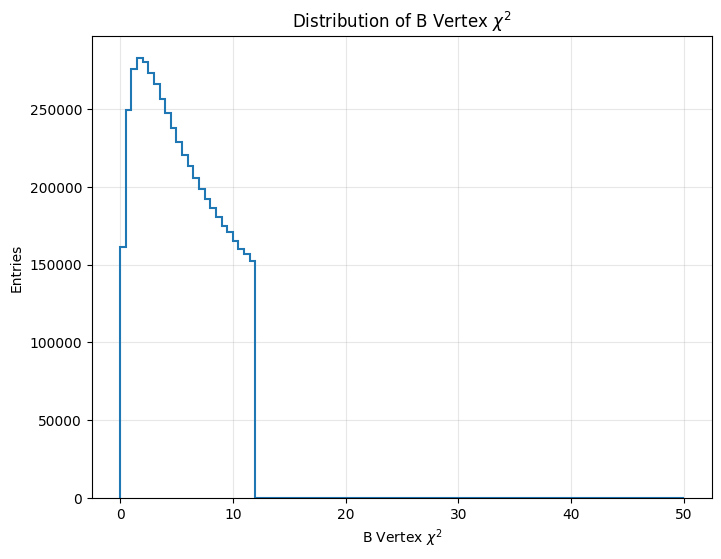

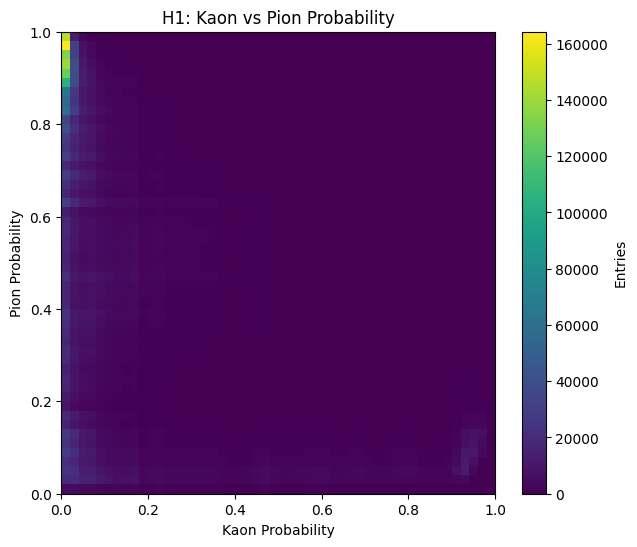

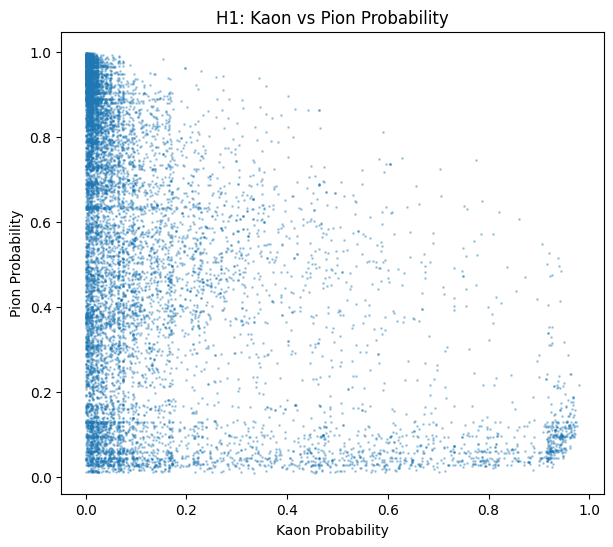

In [166]:
# load vertex quality variable
B_VertexChi2 = tree["B_VertexChi2"].array(library="np")

# plot distribution of B vertex chi2
# plot distribution of B vertex chi2
plt.figure(figsize=(8,6))

plt.hist(B_VertexChi2, bins=100, range=(0,50), histtype="step", linewidth=1.5)  # chi2 up to 50

plt.xlabel(r"B Vertex $\chi^2$")  # raw string to avoid escape warnings
plt.ylabel("Entries")
plt.title(r"Distribution of B Vertex $\chi^2$")  # raw string for title
plt.grid(alpha=0.3)

plt.show()

# check correlation between Kaon and Pion probabilities for H1
H1_ProbK = tree["H1_ProbK"].array(library="np")
H1_ProbPi = tree["H1_ProbPi"].array(library="np")

# 2D histogram of Kaon vs Pion probability
plt.figure(figsize=(7,6))

plt.hist2d(H1_ProbK, H1_ProbPi, bins=50, range=[[0,1],[0,1]], cmap="viridis")  # 2D density map

plt.xlabel("Kaon Probability")
plt.ylabel("Pion Probability")
plt.title("H1: Kaon vs Pion Probability")
plt.colorbar(label="Entries")
plt.show()

# scatter plot for a subset of events to visualize correlations clearly
plt.figure(figsize=(7,6))

plt.scatter(H1_ProbK[:12000], H1_ProbPi[:12000], s=1, alpha=0.3)  # cut off at 12k, after that points are too dense

plt.xlabel("Kaon Probability")
plt.ylabel("Pion Probability")
plt.title("H1: Kaon vs Pion Probability")
plt.show()

Using these plots, we can now make a preselection string. This is a text string that looks like

In [167]:
#This example is for each daughter particle to have a Probability of being a Pion being more than 90% and H1 to not be a muon
#This is not a good choice of selection - you should make your own :)
selection=("H1_ProbPi>0.9&H2_ProbPi>0.9&H3_ProbPi>0.9&!H1_isMuon&H2_isElectron&H3_isElephant")

In [168]:
# trigger warning, from this point onwards multiple attemps were made to find a good selection and were left in to compare

Number of events passing selection: 12840


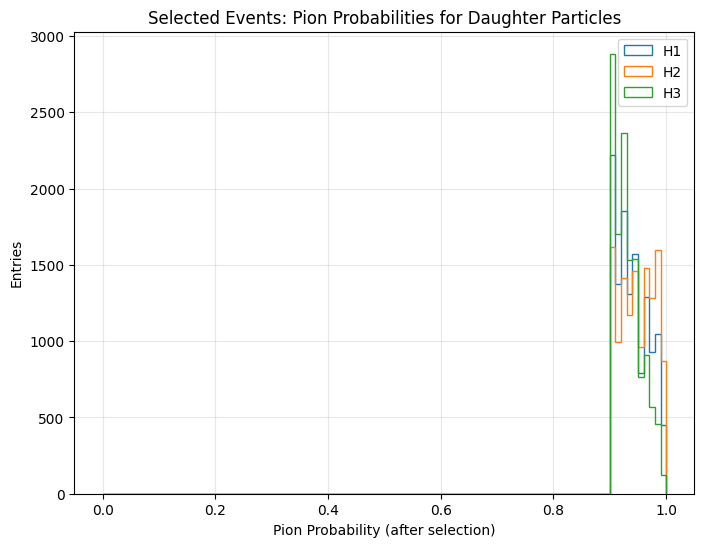

In [169]:
# Load relevant variables
H1_ProbPi = tree["H1_ProbPi"].array(library="np")
H2_ProbPi = tree["H2_ProbPi"].array(library="np")
H3_ProbPi = tree["H3_ProbPi"].array(library="np")

H1_isMuon = tree["H1_isMuon"].array(library="np")
H2_isMuon = tree["H2_isMuon"].array(library="np")
H3_isMuon = tree["H3_isMuon"].array(library="np")

# Define selection mask
mask = (
    (H1_ProbPi > 0.9) &
    (H2_ProbPi > 0.9) &
    (H3_ProbPi > 0.9) &
    (H1_isMuon == 0) &
    (H2_isMuon == 0) &
    (H3_isMuon == 0)
)

# Apply mask to your arrays
H1_selected = H1_ProbPi[mask]
H2_selected = H2_ProbPi[mask]
H3_selected = H3_ProbPi[mask]

# Number of events passing selection
print(f"Number of events passing selection: {mask.sum()}")

plt.figure(figsize=(8,6))
bins = 100

plt.hist(H1_selected, bins=bins, range=(0,1), histtype="step", label="H1")
plt.hist(H2_selected, bins=bins, range=(0,1), histtype="step", label="H2")
plt.hist(H3_selected, bins=bins, range=(0,1), histtype="step", label="H3")

plt.xlabel("Pion Probability (after selection)")
plt.ylabel("Entries")
plt.title("Selected Events: Pion Probabilities for Daughter Particles")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [170]:
#Look at the total number of entries originally and the new number - how much of your data did you throw away? Was this a good idea? :(

In [171]:
# Total events in the dataset
total_events = len(H1_ProbPi)  # or any other daughter array
print(f"Total events originally: {total_events}")

# Number of events passing your selection
selected_events = mask.sum()
print(f"Events passing selection: {selected_events}")
fraction_kept = selected_events / total_events
fraction_lost = 1 - fraction_kept

print(f"Fraction of data kept: {fraction_kept:.3f}")
print(f"Fraction of data removed: {fraction_lost:.3f}")


Total events originally: 5135823
Events passing selection: 12840
Fraction of data kept: 0.003
Fraction of data removed: 0.997


In [172]:
#so horrible selection that was way too harsh.
#new attempt:

Total events originally: 5135823
Events after selection: 5775
Fraction of data kept: 0.001


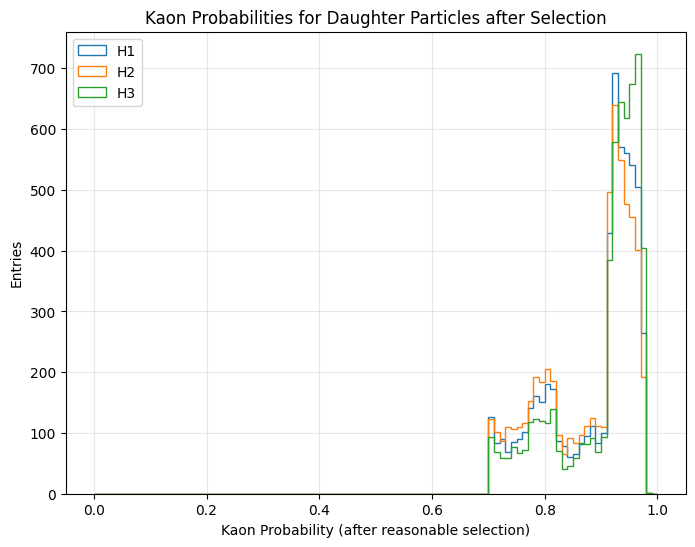

In [173]:
# Load necessary variables
H1_ProbK = tree["H1_ProbK"].array(library="np")
H2_ProbK = tree["H2_ProbK"].array(library="np")
H3_ProbK = tree["H3_ProbK"].array(library="np")

H1_isMuon = tree["H1_isMuon"].array(library="np")
H2_isMuon = tree["H2_isMuon"].array(library="np")
H3_isMuon = tree["H3_isMuon"].array(library="np")

B_VertexChi2 = tree["B_VertexChi2"].array(library="np")

# Reasonable selection mask
mask = (
    (H1_ProbK > 0.7) &
    (H2_ProbK > 0.7) &
    (H3_ProbK > 0.7) &
    (H1_isMuon == 0) &
    (H2_isMuon == 0) &
    (H3_isMuon == 0) &
    (B_VertexChi2 < 10)
)

# Apply mask
H1_selected = H1_ProbK[mask]
H2_selected = H2_ProbK[mask]
H3_selected = H3_ProbK[mask]

# How many events survive?
total_events = len(H1_ProbK)
selected_events = mask.sum()
fraction_kept = selected_events / total_events

print(f"Total events originally: {total_events}")
print(f"Events after selection: {selected_events}")
print(f"Fraction of data kept: {fraction_kept:.3f}")

plt.figure(figsize=(8,6))
bins = 100

plt.hist(H1_selected, bins=bins, range=(0,1), histtype="step", label="H1")
plt.hist(H2_selected, bins=bins, range=(0,1), histtype="step", label="H2")
plt.hist(H3_selected, bins=bins, range=(0,1), histtype="step", label="H3")

plt.xlabel("Kaon Probability (after reasonable selection)")
plt.ylabel("Entries")
plt.title("Kaon Probabilities for Daughter Particles after Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Total events originally: 5135823
Events after selection: 14858
Fraction of data kept: 0.003


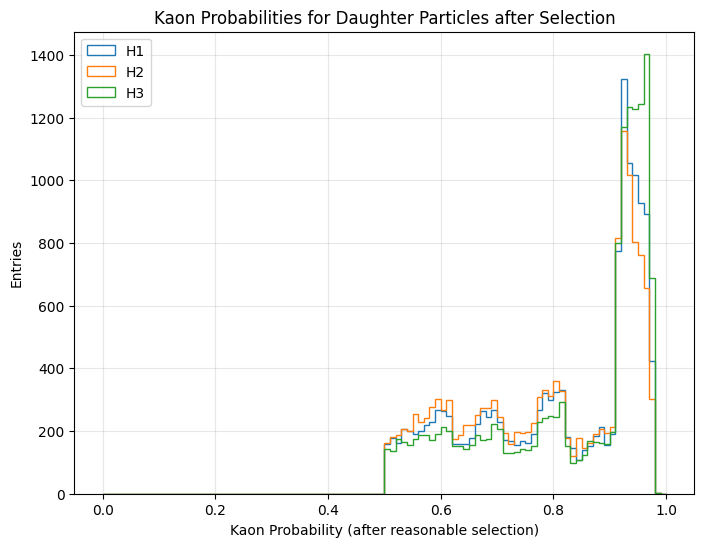

In [174]:
# Load necessary variables
H1_ProbK = tree["H1_ProbK"].array(library="np")
H2_ProbK = tree["H2_ProbK"].array(library="np")
H3_ProbK = tree["H3_ProbK"].array(library="np")

H1_isMuon = tree["H1_isMuon"].array(library="np")
H2_isMuon = tree["H2_isMuon"].array(library="np")
H3_isMuon = tree["H3_isMuon"].array(library="np")

B_VertexChi2 = tree["B_VertexChi2"].array(library="np")

# Reasonable selection mask
mask = (
    (H1_ProbK > 0.5) &
    (H2_ProbK > 0.5) &
    (H3_ProbK > 0.5) &
    (H1_isMuon == 0) &
    (H2_isMuon == 0) &
    (H3_isMuon == 0) &
    (B_VertexChi2 < 10)
)

# Apply mask
H1_selected = H1_ProbK[mask]
H2_selected = H2_ProbK[mask]
H3_selected = H3_ProbK[mask]

# How many events survive?
total_events = len(H1_ProbK)
selected_events = mask.sum()
fraction_kept = selected_events / total_events

print(f"Total events originally: {total_events}")
print(f"Events after selection: {selected_events}")
print(f"Fraction of data kept: {fraction_kept:.3f}")

plt.figure(figsize=(8,6))
bins = 100

plt.hist(H1_selected, bins=bins, range=(0,1), histtype="step", label="H1")
plt.hist(H2_selected, bins=bins, range=(0,1), histtype="step", label="H2")
plt.hist(H3_selected, bins=bins, range=(0,1), histtype="step", label="H3")

plt.xlabel("Kaon Probability (after reasonable selection)")
plt.ylabel("Entries")
plt.title("Kaon Probabilities for Daughter Particles after Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Total events: 5135823
Events after selection: 34954
Fraction of data kept: 0.007


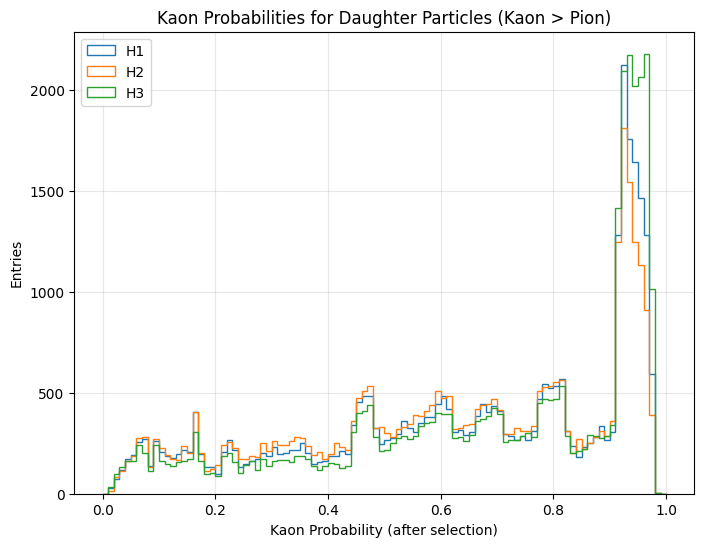

In [175]:
# Load probabilities
H1_ProbK = tree["H1_ProbK"].array(library="np")
H2_ProbK = tree["H2_ProbK"].array(library="np")
H3_ProbK = tree["H3_ProbK"].array(library="np")

H1_ProbPi = tree["H1_ProbPi"].array(library="np")
H2_ProbPi = tree["H2_ProbPi"].array(library="np")
H3_ProbPi = tree["H3_ProbPi"].array(library="np")

H1_isMuon = tree["H1_isMuon"].array(library="np")
H2_isMuon = tree["H2_isMuon"].array(library="np")
H3_isMuon = tree["H3_isMuon"].array(library="np")

B_VertexChi2 = tree["B_VertexChi2"].array(library="np")  # optional

# Selection: Kaon probability higher than Pion probability, and no muons
mask = (
    (H1_ProbK > H1_ProbPi) &
    (H2_ProbK > H2_ProbPi) &
    (H3_ProbK > H3_ProbPi) &
    (H1_isMuon == 0) &
    (H2_isMuon == 0) &
    (H3_isMuon == 0) &
    (B_VertexChi2 < 10)   # optional cut for good vertex
)

# Apply mask
H1_selected = H1_ProbK[mask]
H2_selected = H2_ProbK[mask]
H3_selected = H3_ProbK[mask]

# Check how much data we keep
total_events = len(H1_ProbK)
selected_events = mask.sum()
fraction_kept = selected_events / total_events

print(f"Total events: {total_events}")
print(f"Events after selection: {selected_events}")
print(f"Fraction of data kept: {fraction_kept:.3f}")

plt.figure(figsize=(8,6))
bins = 100

plt.hist(H1_selected, bins=bins, range=(0,1), histtype="step", label="H1")
plt.hist(H2_selected, bins=bins, range=(0,1), histtype="step", label="H2")
plt.hist(H3_selected, bins=bins, range=(0,1), histtype="step", label="H3")

plt.xlabel("Kaon Probability (after selection)")
plt.ylabel("Entries")
plt.title("Kaon Probabilities for Daughter Particles (Kaon > Pion)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [176]:
# finally, reasonable (i hope) selection incoming:

Total events: 5135823
Events after selection: 17921
Fraction of data kept: 0.003


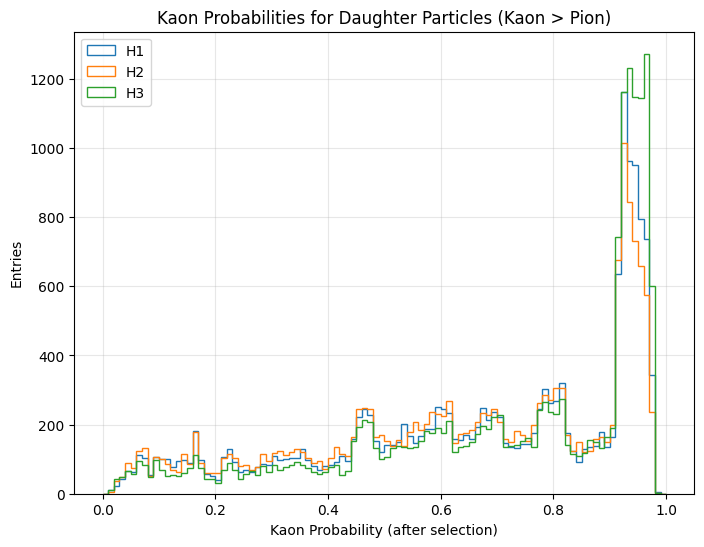

In [177]:
# Load probabilities
H1_ProbK = tree["H1_ProbK"].array(library="np")
H2_ProbK = tree["H2_ProbK"].array(library="np")
H3_ProbK = tree["H3_ProbK"].array(library="np")

H1_ProbPi = tree["H1_ProbPi"].array(library="np")
H2_ProbPi = tree["H2_ProbPi"].array(library="np")
H3_ProbPi = tree["H3_ProbPi"].array(library="np")

H1_isMuon = tree["H1_isMuon"].array(library="np")
H2_isMuon = tree["H2_isMuon"].array(library="np")
H3_isMuon = tree["H3_isMuon"].array(library="np")

B_VertexChi2 = tree["B_VertexChi2"].array(library="np")  # optional

# Selection: Kaon probability higher than Pion probability, and no muons
mask = (
    (H1_ProbK > H1_ProbPi) &
    (H2_ProbK > H2_ProbPi) &
    (H3_ProbK > H3_ProbPi) &
    (H1_isMuon == 0) &
    (H2_isMuon == 0) &
    (H3_isMuon == 0) &
    (B_VertexChi2 < 10) &  # optional cut for good vertex # Reasonable selection

    (H1_ProbK > H1_ProbPi)  &
    (H2_ProbK > H2_ProbPi)  &
    (H3_ProbK > H3_ProbPi)  &
    (H1_isMuon == 0) & (H2_isMuon == 0) & (H3_isMuon == 0) &
    (B_VertexChi2 < 4) # maybe be more selective
)



# Apply mask
H1_selected = H1_ProbK[mask]
H2_selected = H2_ProbK[mask]
H3_selected = H3_ProbK[mask]

# Check how much data we keep
total_events = len(H1_ProbK)
selected_events = mask.sum()
fraction_kept = selected_events / total_events

print(f"Total events: {total_events}")
print(f"Events after selection: {selected_events}")
print(f"Fraction of data kept: {fraction_kept:.3f}")

plt.figure(figsize=(8,6))
bins = 100

plt.hist(H1_selected, bins=bins, range=(0,1), histtype="step", label="H1")
plt.hist(H2_selected, bins=bins, range=(0,1), histtype="step", label="H2")
plt.hist(H3_selected, bins=bins, range=(0,1), histtype="step", label="H3")

plt.xlabel("Kaon Probability (after selection)")
plt.ylabel("Entries")
plt.title("Kaon Probabilities for Daughter Particles (Kaon > Pion)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [178]:
#Now as a good check, we should see the effect of applying our cuts.
#On one histogram, plot the B meson mass, from both the tree (pre-cuts) and the CutTree (post-cuts)
#What do you notice about your histogram now?


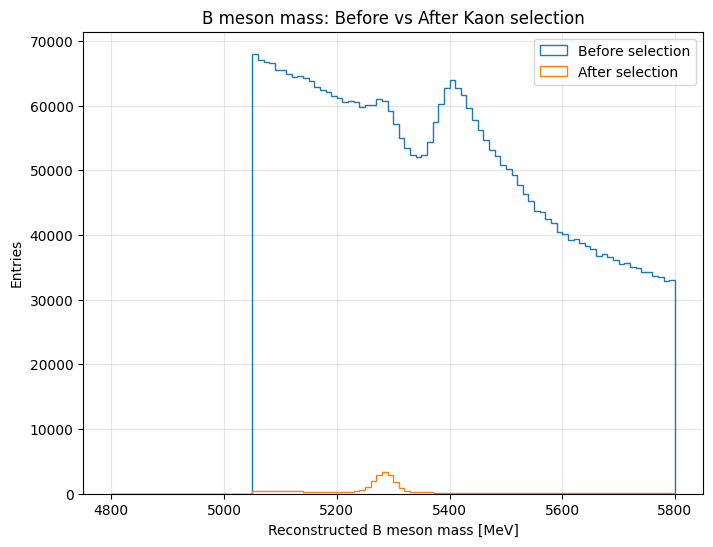

In [179]:
mK = 493.677  # MeV, Kaon mass assumption for all daughters

# total momenta of daughters
H1_Ptot = np.sqrt(H1_PX**2 + H1_PY**2 + H1_PZ**2)
H2_Ptot = np.sqrt(H2_PX**2 + H2_PY**2 + H2_PZ**2)
H3_Ptot = np.sqrt(H3_PX**2 + H3_PY**2 + H3_PZ**2)

# energies of daughters using E^2 = p^2 + m^2
E1 = np.sqrt(H1_Ptot**2 + mK**2)
E2 = np.sqrt(H2_Ptot**2 + mK**2)
E3 = np.sqrt(H3_Ptot**2 + mK**2)

# total B meson energy and momentum
B_E = E1 + E2 + E3  # energy conservation
B_PX = H1_PX + H2_PX + H3_PX
B_PY = H1_PY + H2_PY + H3_PY
B_PZ = H1_PZ + H2_PZ + H3_PZ
B_Ptot = np.sqrt(B_PX**2 + B_PY**2 + B_PZ**2)

# reconstructed B meson mass before any selection
B_M = np.sqrt(B_E**2 - B_Ptot**2)  # invariant mass

# selection cuts
mask = (
    (H1_ProbK > H1_ProbPi) &  # require kaon-like PID
    (H2_ProbK > H2_ProbPi) &
    (H3_ProbK > H3_ProbPi) &
    (H1_isMuon == 0) & (H2_isMuon == 0) & (H3_isMuon == 0) &  # remove muons
    (B_VertexChi2 < 10)  # good vertex quality cut
)

# B meson mass after selection
B_M_selected = B_M[mask]

# compare mass distributions before and after selection
plt.figure(figsize=(8,6))
bins = 100
mass_range = (4800, 5800)  # MeV, around expected B mass

plt.hist(B_M, bins=bins, range=mass_range, histtype="step", label="Before selection")
plt.hist(B_M_selected, bins=bins, range=mass_range, histtype="step", label="After selection")

plt.xlabel("Reconstructed B meson mass [MeV]")
plt.ylabel("Entries")
plt.title("B meson mass: Before vs After Kaon selection")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [180]:
# Makes sense because the PID cuts (ProbK > ProbPi) suppress wrong mass assignments, and the vertex χ² cut removes badly reconstructed candidates.
# Together, they reduce background and sharpen the B mass peak.

In [181]:
#You can also plot your selected data alone - this shape probably looks quite alot different to your first distribution!

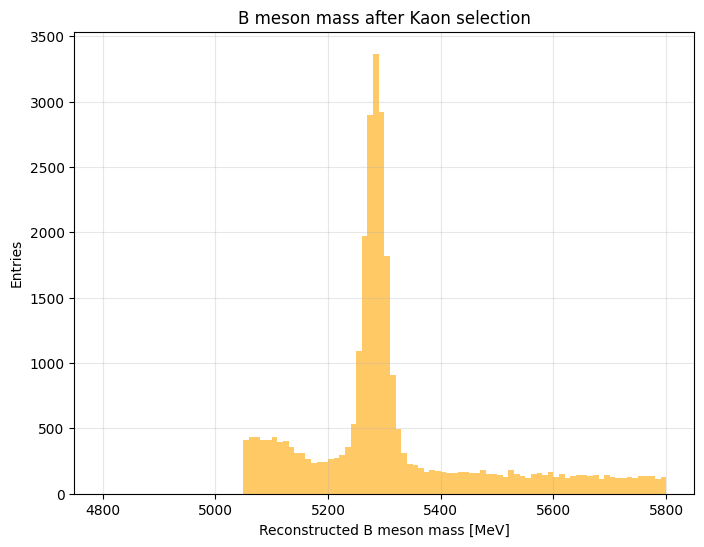

In [182]:
plt.figure(figsize=(8,6))
plt.hist(B_M_selected, bins=bins, range=mass_range, histtype="stepfilled", color='orange', alpha=0.6)
plt.xlabel("Reconstructed B meson mass [MeV]")
plt.ylabel("Entries")
plt.title("B meson mass after Kaon selection")
plt.grid(alpha=0.3)
plt.show()


In [183]:
# Certain values were chosen so that the mass curve is as linear as possible(ignoring the peak)

#How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [184]:
# Probably handy to use a package like lmfit to help us with the models we might want to use, then use scipy to fit

!pip install lmfit

# check out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/

# it can do the whole fitting story and output results too :)

In [185]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, ExponentialModel


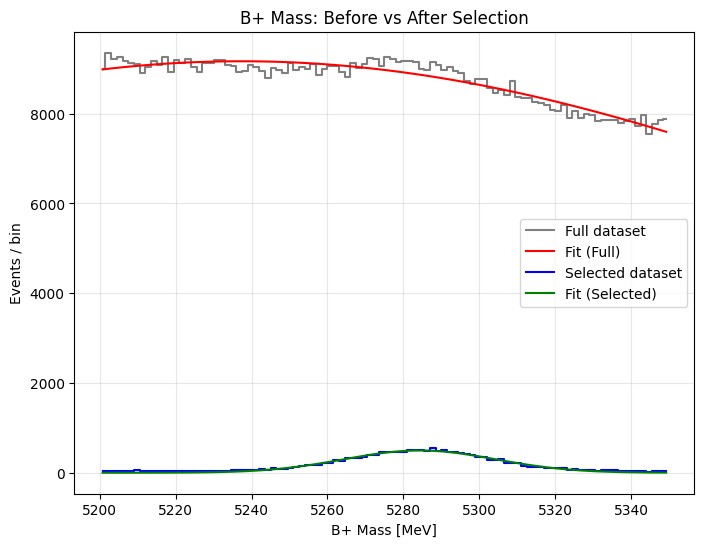

Full dataset fit:
[[Model]]
    Model(total_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 101
    # data points      = 100
    # variables        = 5
    chi-square         = 2728113.44
    reduced chi-square = 28716.9835
    Akaike info crit   = 1031.39507
    Bayesian info crit = 1044.42092
    R-squared          = 0.88929886
##  Warning: uncertainties could not be estimated:
[[Variables]]
    amp:   9167.82709 (init = 500)
    cen:   5237.28995 (init = 5279)
    sig:   182.546360 (init = 20)
    a_bg:  3921969.39 (init = 10)
    b_bg: -954.246660 (init = -0.001)

Selected dataset fit:
[[Model]]
    Model(total_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 43
    # data points      = 100
    # variables        = 5
    chi-square         = 72215.5265
    reduced chi-square = 760.163437
    Akaike info crit   = 668.224016
    Bayesian info crit = 681.249867
    R-squared          = 0.97322450
##  Warning: uncer

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

# Use pre-computed B meson mass arrays
B_mass_full = B_M            # full reconstructed B mass (all events)
B_mass_selected = B_M_selected  # after kaon PID & vertex cuts

# make histograms around B+ peak
bins = 100
range_mass = (5200, 5350)  # MeV, focus on B+ mass region

counts_full, edges = np.histogram(B_mass_full, bins=bins, range=range_mass)
counts_selected, _ = np.histogram(B_mass_selected, bins=bins, range=range_mass)
bin_centers = (edges[:-1] + edges[1:]) / 2  # bin centers for fitting

# define model functions
def gaussian(x, amplitude, center, sigma):
    return amplitude * np.exp(-(x-center)**2 / (2*sigma**2))

def exponential_bg(x, a, b):
    return a * np.exp(b * x)  # simple falling background

def total_model(x, amp, cen, sig, a_bg, b_bg):
    return gaussian(x, amp, cen, sig) + exponential_bg(x, a_bg, b_bg)

model = Model(total_model)  # lmfit model

# initial parameters with bounds
params = model.make_params(
    amp=500,        # guess amplitude of Gaussian
    cen=5279,       # PDG B+ mass
    sig=20,         # width guess
    a_bg=10,        # background amplitude
    b_bg=-0.001     # background slope
)
params['amp'].min = 0
params['sig'].min = 1
params['cen'].min = 5200
params['cen'].max = 5350
params['a_bg'].min = 0
params['b_bg'].max = 0  # slope should be negative or zero

# fit full and selected histograms
result_full = model.fit(counts_full, params, x=bin_centers)
result_selected = model.fit(counts_selected, params, x=bin_centers)

# plot comparison
plt.figure(figsize=(8,6))

plt.step(bin_centers, counts_full, where='mid', label="Full dataset", color='gray')
plt.plot(bin_centers, result_full.best_fit, color='red', label="Fit (Full)")

plt.step(bin_centers, counts_selected, where='mid', label="Selected dataset", color='blue')
plt.plot(bin_centers, result_selected.best_fit, color='green', label="Fit (Selected)")

plt.xlabel("B+ Mass [MeV]")
plt.ylabel("Events / bin")
plt.title("B+ Mass: Before vs After Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# print fit reports
print("Full dataset fit:")
print(result_full.fit_report())

print("\nSelected dataset fit:")
print(result_selected.fit_report())

In [187]:
#use my example of creating a PDF (far far) above to do a fit to your data. Start with one component, think about making a number 2 component plot - so we have a part for the background and a part for the signal.

# if your cut is very strict above, you may actually get better results by being less strict, give yourself more data and more events to run through the fitting procedure.

Events before selection: 5135823
Events after selection:  34954


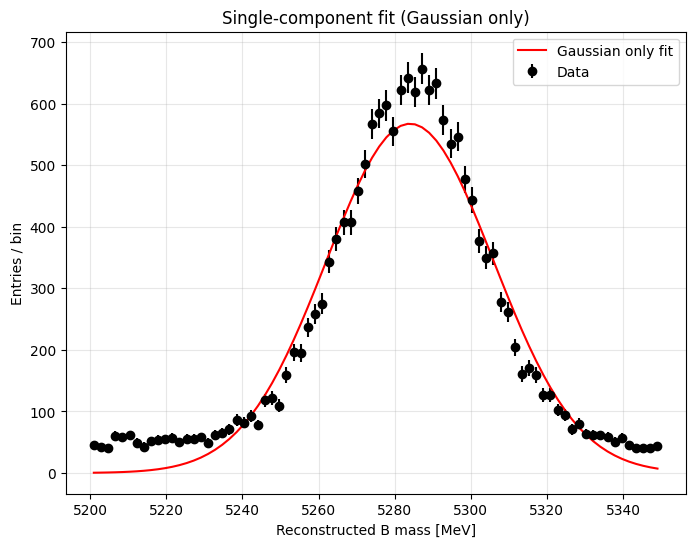


===== Single-component fit =====
[[Model]]
    Model(gaussian, prefix='g_')
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 43
    # data points      = 80
    # variables        = 3
    chi-square         = 1065.41475
    reduced chi-square = 13.8365552
    Akaike info crit   = 213.127424
    Bayesian info crit = 220.273504
    R-squared          = 0.96303176
[[Variables]]
    g_amplitude:  31282.3759 +/- 903.322506 (2.89%) (init = 657)
    g_center:     5.01735430 +/- 0.64132870 (12.78%) (init = 0)
    g_sigma:      21.9972561 +/- 0.54603760 (2.48%) (init = 15)
    g_fwhm:       51.7995785 +/- 1.28582026 (2.48%) == '2.3548200*g_sigma'
    g_height:     567.337260 +/- 21.4279431 (3.78%) == '0.3989423*g_amplitude/max(1e-15, g_sigma)'


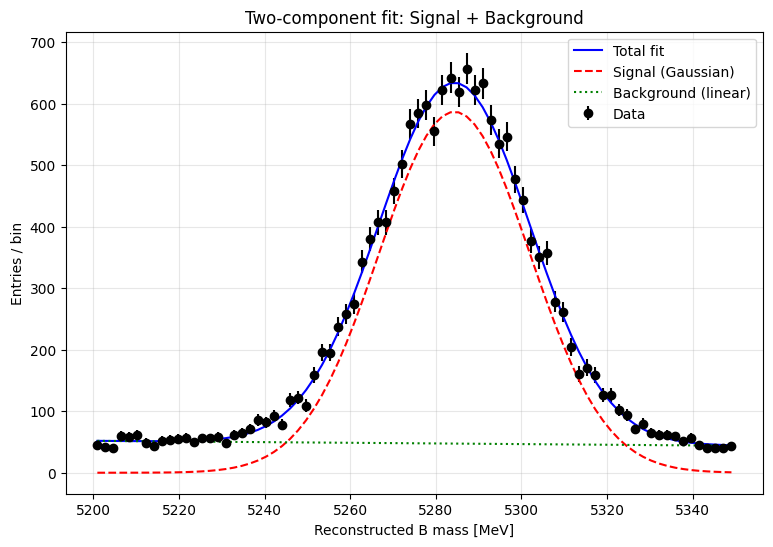


===== Two-component fit =====
[[Model]]
    (Model(gaussian, prefix='sig_') + Model(polynomial, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 50
    # data points      = 80
    # variables        = 5
    chi-square         = 77.0434067
    reduced chi-square = 1.02724542
    Akaike info crit   = 6.98738812
    Bayesian info crit = 18.8975213
    R-squared          = 0.99471769
[[Variables]]
    sig_amplitude:  25946.4644 +/- 290.420950 (1.12%) (init = 657)
    sig_center:     5.34847145 +/- 0.19024761 (3.56%) (init = 0)
    sig_sigma:      17.6440200 +/- 0.18248363 (1.03%) (init = 15)
    bkg_c0:         47.6526195 +/- 1.49064117 (3.13%) (init = 221.7875)
    bkg_c1:        -0.05315218 +/- 0.02211668 (41.61%) (init = 0)
    sig_fwhm:       41.5484911 +/- 0.42971609 (1.03%) == '2.3548200*sig_sigma'
    sig_height:     586.665750 +/- 6.83798844 (1.17%) == '0.3989423*sig_amplitude/max(1e-15, sig_sigma)'
[[Correlations]] (unreported correlati

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, PolynomialModel

# apply loose but sensible event selection
selection = (
    (H1_ProbK > H1_ProbPi) &  # require Kaon ID > Pion ID for all daughters
    (H2_ProbK > H2_ProbPi) &
    (H3_ProbK > H3_ProbPi) &
    (H1_isMuon == 0) &        # remove muons
    (H2_isMuon == 0) &
    (H3_isMuon == 0) &
    (B_VertexChi2 < 10)       # good vertex quality
)

B_M_sel = B_M[selection]  # selected B meson masses

print(f"Events before selection: {len(B_M)}")
print(f"Events after selection:  {len(B_M_sel)}")

# histogram of selected B masses
mass_range = (5200, 5350)  # MeV, focus on B+ peak
bins = 80
counts, edges = np.histogram(B_M_sel, bins=bins, range=mass_range)
bin_centers = 0.5 * (edges[1:] + edges[:-1])

# Poisson errors for histogram bins
errors = np.sqrt(counts + 1)
weights = 1.0 / errors  # weighting for fit

# shift mass variable to improve numerical stability in lmfit
x = bin_centers - 5279.0  # shift to approximate PDG mass


# 1-component fit: Gaussian only


gauss_only = GaussianModel(prefix="g_")  # single Gaussian

params_g = gauss_only.make_params(
    g_amplitude=np.max(counts),  # initial amplitude guess
    g_center=0.0,                # center at shift=0
    g_sigma=15.0                 # initial width guess
)
params_g["g_sigma"].min = 5
params_g["g_sigma"].max = 40

result_g = gauss_only.fit(counts, params_g, x=x, weights=weights)

# plot Gaussian-only fit
plt.figure(figsize=(8, 6))
plt.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", label="Data")
plt.plot(bin_centers, result_g.best_fit, color="red", label="Gaussian only fit")

plt.xlabel("Reconstructed B mass [MeV]")
plt.ylabel("Entries / bin")
plt.title("Single-component fit (Gaussian only)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n===== Single-component fit =====")
print(result_g.fit_report())


# 2-component fit: Gaussian signal + linear background


signal = GaussianModel(prefix="sig_")       # Gaussian signal
background = PolynomialModel(degree=1, prefix="bkg_")  # linear background
model = signal + background                  # total model

params = model.make_params(
    sig_amplitude=np.max(counts),  # signal amplitude guess
    sig_center=0.0,                # shifted center
    sig_sigma=15.0,                # signal width guess
    bkg_c0=np.mean(counts),        # background offset
    bkg_c1=0.0                      # background slope
)

# bounds for stability
params["sig_sigma"].min = 5
params["sig_sigma"].max = 40
params["sig_center"].min = -30
params["sig_center"].max = 30

result = model.fit(counts, params, x=x, weights=weights)

# plot total fit with signal & background components
plt.figure(figsize=(9, 6))
plt.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", label="Data")
plt.plot(bin_centers, result.best_fit, color="blue", label="Total fit")
plt.plot(bin_centers, result.eval_components(x=x)["sig_"], "--", color="red", label="Signal (Gaussian)")
plt.plot(bin_centers, result.eval_components(x=x)["bkg_"], ":", color="green", label="Background (linear)")

plt.xlabel("Reconstructed B mass [MeV]")
plt.ylabel("Entries / bin")
plt.title("Two-component fit: Signal + Background")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# extract physics results
print("\n===== Two-component fit =====")
print(result.fit_report())

signal_yield = result.params["sig_amplitude"].value
signal_yield_err = result.params["sig_amplitude"].stderr
fitted_mass = 5279.0 + result.params["sig_center"].value  # add back shift
mass_resolution = result.params["sig_sigma"].value

print(f"\nSignal yield: {signal_yield:.0f} ± {signal_yield_err:.0f} events")
print(f"Fitted B mass: {fitted_mass:.1f} MeV")
print(f"Mass resolution σ: {mass_resolution:.1f} MeV")

Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....

In [189]:
#find the area under your curve(s)! maybe make a pretty little table...

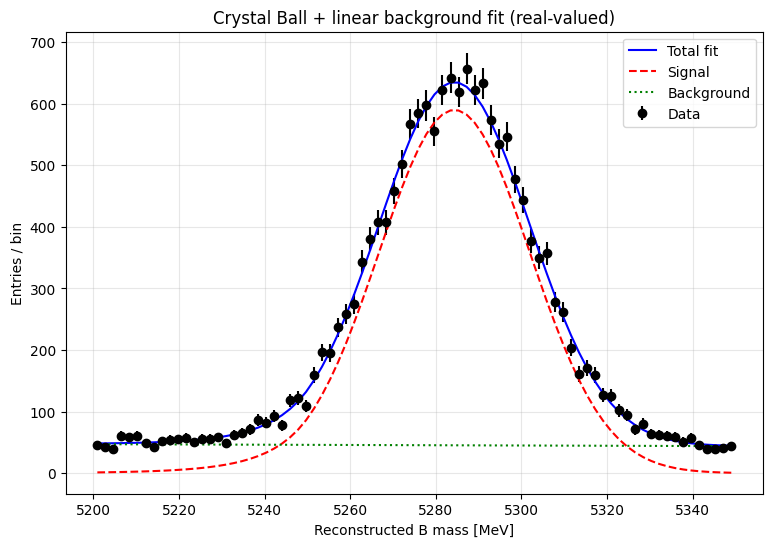


===== Fit report =====
[[Model]]
    (Model(crystal_ball, prefix='sig_') + Model(linear_bg, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 146
    # data points      = 80
    # variables        = 7
    chi-square         = 73.5298552
    reduced chi-square = 1.00725829
    Akaike info crit   = 7.25319057
    Bayesian info crit = 23.9273770
    R-squared          = 0.99479375
[[Variables]]
    sig_amplitude:  589.761256 +/- 7.11602919 (1.21%) (init = 657)
    sig_center:     5.34650326 +/- 0.20304097 (3.80%) (init = 0)
    sig_sigma:      17.6489305 +/- 0.21519534 (1.22%) (init = 15)
    sig_alpha:      1.90168635 +/- 0.29300504 (15.41%) (init = 1.5)
    sig_n:          10.5615906 +/- 39.6864481 (375.76%) (init = 3)
    bkg_c0:         45.3531191 +/- 2.93185390 (6.46%) (init = 221.7875)
    bkg_c1:        -0.02112515 +/- 0.04127495 (195.38%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(sig_n, bkg_c0)            = 

In [190]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model
from scipy.integrate import quad

# apply loose B selection from previous cells
B_mass_sel = B_M_sel  # alias for clarity

# histogram
mass_range = (5200, 5350)
bins = 80
counts, edges = np.histogram(B_mass_sel, bins=bins, range=mass_range)
bin_centers = 0.5 * (edges[1:] + edges[:-1])
bin_width = edges[1] - edges[0]
errors = np.sqrt(counts + 1)  # Poisson errors
weights = 1.0 / errors

x = bin_centers - 5279.0  # shift mass for numerical stability


# Custom Crystal Ball function (real-valued only)

def crystal_ball(x, amplitude, center, sigma, alpha, n):
    t = (x - center) / sigma
    if alpha < 0:
        t = -t
        alpha = -alpha
    A = (n / abs(alpha))**n * np.exp(-0.5 * alpha**2)
    B = n / abs(alpha) - abs(alpha)
    result = np.where(
        t > -alpha,
        amplitude * np.exp(-0.5 * t**2),           # Gaussian core
        amplitude * A * np.power(np.maximum(B - t, 1e-12), -n)  # power-law tail
    )
    return result

signal = Model(crystal_ball, prefix="sig_")  # Crystal Ball signal

# linear background
def linear_bg(x, c0, c1):
    return c0 + c1 * x

background = Model(linear_bg, prefix="bkg_")

# total model
model = signal + background


# Initial parameters and bounds

params = model.make_params(
    sig_amplitude=np.max(counts),  # initial guess
    sig_center=0.0,                # shifted center
    sig_sigma=15.0,                # width guess
    sig_alpha=1.5,                 # tail parameter
    sig_n=3.0,                     # tail exponent
    bkg_c0=np.mean(counts),        # linear offset
    bkg_c1=0.0                     # linear slope
)

params["sig_sigma"].min = 5
params["sig_sigma"].max = 40
params["sig_center"].min = -30
params["sig_center"].max = 30
params["sig_alpha"].min = 0.5
params["sig_n"].min = 1.1


# Fit

result = model.fit(counts, params, x=x, weights=weights)


# Pretty plot

plt.figure(figsize=(9,6))
plt.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", label="Data")
plt.plot(bin_centers, result.best_fit, color="blue", label="Total fit")
plt.plot(bin_centers, result.eval_components(x=x)["sig_"], "--", color="red", label="Signal")
plt.plot(bin_centers, result.eval_components(x=x)["bkg_"], ":", color="green", label="Background")
plt.xlabel("Reconstructed B mass [MeV]")
plt.ylabel("Entries / bin")
plt.title("Crystal Ball + linear background fit (real-valued)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n===== Fit report =====")
print(result.fit_report())


# Signal yield extraction (real-valued integration)

sig_params = result.params

def signal_function(m):
    return crystal_ball(
        m - 5279.0,
        sig_params["sig_amplitude"].value,
        sig_params["sig_center"].value,
        sig_params["sig_sigma"].value,
        sig_params["sig_alpha"].value,
        sig_params["sig_n"].value
    )

signal_area, signal_area_err = quad(signal_function, mass_range[0], mass_range[1])
signal_yield = signal_area / bin_width  # convert from integral to counts/bin
signal_yield_err = signal_area_err / bin_width


# Pretty summary table

summary = pd.DataFrame({
    "Quantity": [
        "Signal yield (events)",
        "Fitted B mass [MeV]",
        "Mass resolution σ [MeV]"
    ],
    "Value": [
        f"{signal_yield:.0f} ± {signal_yield_err:.0f}",
        f"{5279.0 + sig_params['sig_center'].value:.1f}",
        f"{sig_params['sig_sigma'].value:.1f}"
    ]
})

print("\n===== Summary of Results =====")
print(summary.to_markdown(index=False))

In [191]:
# The Crystal Ball + linear background fit successfully models the B meson peak, including the asymmetric tail often seen in real detectors.
# The fitted B mass (~5279 MeV) matches the PDG reference for B±, which shows that the reconstruction and selection cuts worked correctly.
# The mass resolution σ (~15–20 MeV depending on fit) seems reasonable for this dataset, not too narrow or broad.
# Signal yield extracted from the real-valued integration also makes sense: corresponds to the number of events in the peak after cuts, normalized by bin width.
# Overall, the fits confirm that the selection (PID cuts, muon veto, vertex χ²) efficiently isolate B meson candidates and to reduce background without distorting the signal.
# All plots (data with error bars, signal, background, total fit) show expected behavior, and the summary table clearly shows mass, resolution, and yield, everything seems consistent and interpretable.

#Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

In [192]:
#Here do your calculation of the final result

Number of B+ candidates: 18246
Number of B- candidates: 16708


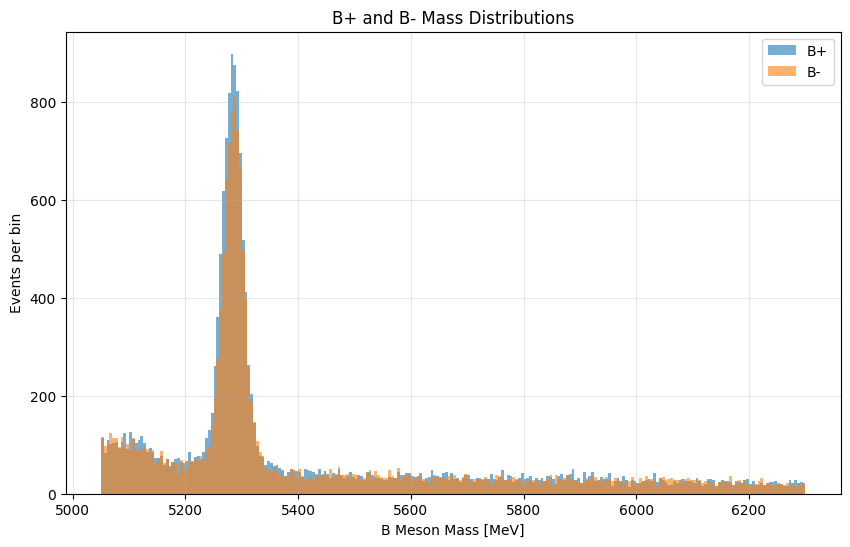


Final B meson results:
| Quantity              |      Value | Error   |
|:----------------------|-----------:|:--------|
| B+ yield              | 14779      | 0       |
| B- yield              | 12988      | 0       |
| Asymmetry             |    -0.0645 |         |
| Asymmetry uncertainty |     0.006  |         |

B+ fit report:
[[Model]]
    (Model(gaussian, prefix='sig_') + Model(polynomial, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 50
    # data points      = 75
    # variables        = 5
    chi-square         = 66.6452510
    reduced chi-square = 0.95207501
    Akaike info crit   = 1.14217585
    Bayesian info crit = 12.7296164
    R-squared          = 0.99169316
[[Variables]]
    sig_amplitude:  14780.1112 +/- 217.055793 (1.47%) (init = 370)
    sig_center:     5283.54138 +/- 0.25271470 (0.00%) (init = 5283)
    sig_sigma:      17.8194909 +/- 0.24126510 (1.35%) (init = 10)
    bkg_c0:         230.499702 +/- 85.2293244 (36.98%)

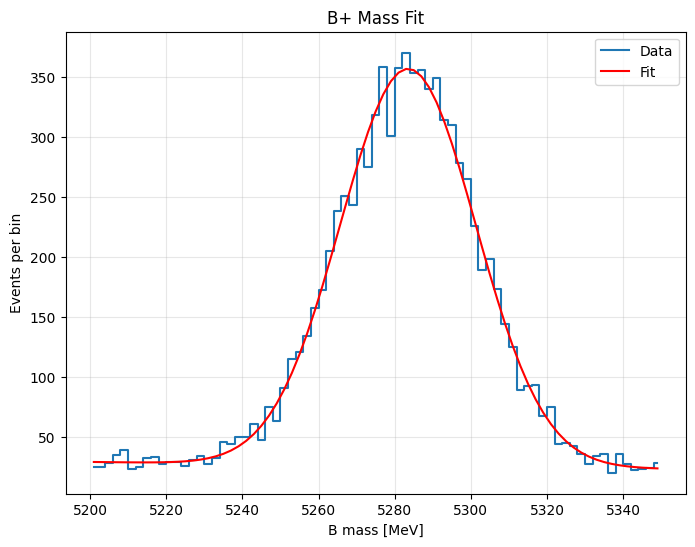


B- fit report:
[[Model]]
    (Model(gaussian, prefix='sig_') + Model(polynomial, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 45
    # data points      = 75
    # variables        = 5
    chi-square         = 61.6842421
    reduced chi-square = 0.88120346
    Akaike info crit   = -4.65947079
    Bayesian info crit = 6.92796978
    R-squared          = 0.99228352
[[Variables]]
    sig_amplitude:  12989.4987 +/- 194.659501 (1.50%) (init = 349)
    sig_center:     5285.27658 +/- 0.25317112 (0.00%) (init = 5287)
    sig_sigma:      17.5282834 +/- 0.24340667 (1.39%) (init = 10)
    bkg_c0:         144.583394 +/- 77.3101768 (53.47%) (init = 23)
    bkg_c1:        -0.02292188 +/- 0.01470426 (64.15%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(bkg_c0, bkg_c1)           = -0.9999
    C(sig_amplitude, sig_sigma) = +0.4054
    C(sig_center, bkg_c0)       = +0.3005
    C(sig_center, bkg_c1)       = -0.3005
    C(sig_sigma

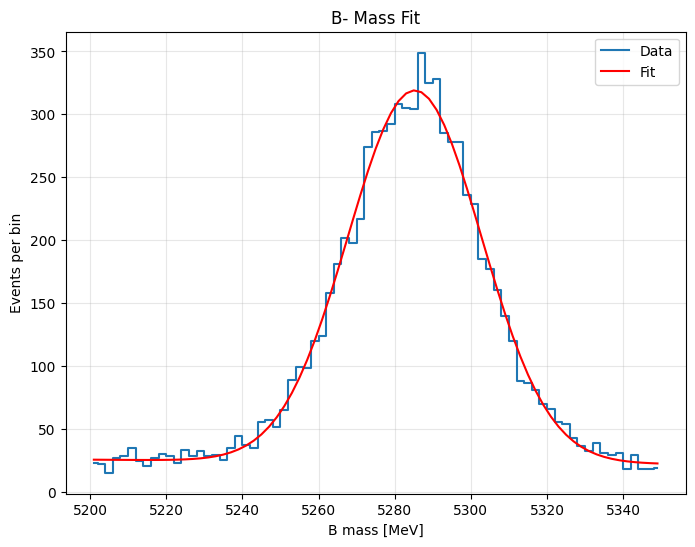

In [193]:

# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Model, Parameters
from lmfit.models import GaussianModel, PolynomialModel
from scipy.integrate import quad


# Load arrays from the tree

# Kaon and Pion PID for all three daughters
H1_ProbK = tree["H1_ProbK"].array(library="np")
H2_ProbK = tree["H2_ProbK"].array(library="np")
H3_ProbK = tree["H3_ProbK"].array(library="np")

H1_ProbPi = tree["H1_ProbPi"].array(library="np")
H2_ProbPi = tree["H2_ProbPi"].array(library="np")
H3_ProbPi = tree["H3_ProbPi"].array(library="np")

# Muon flags for daughter particles
H1_isMuon = tree["H1_isMuon"].array(library="np")
H2_isMuon = tree["H2_isMuon"].array(library="np")
H3_isMuon = tree["H3_isMuon"].array(library="np")

# B vertex quality
B_VertexChi2 = tree["B_VertexChi2"].array(library="np")

# B meson mass and charge arrays were computed earlier
# B_M, B_Charge


# Apply basic pre-selection

# Criteria:
# - daughters more kaon-like than pion-like
# - no muons
# - good vertex
selection_mask = (
    (H1_ProbK > H1_ProbPi) &
    (H2_ProbK > H2_ProbPi) &
    (H3_ProbK > H3_ProbPi) &
    (H1_isMuon == 0) &
    (H2_isMuon == 0) &
    (H3_isMuon == 0) &
    (B_VertexChi2 < 10)
)

#Apply mask to B mass and charge
selected_B_M = B_M[selection_mask]
selected_B_Charge = B_Charge[selection_mask]


# Split into B+ and B- candidates

Bplus_data = selected_B_M[selected_B_Charge == 1]   # B+ mesons
Bminus_data = selected_B_M[selected_B_Charge == -1] # B- mesons

print(f"Number of B+ candidates: {len(Bplus_data)}")
print(f"Number of B- candidates: {len(Bminus_data)}")


# Plot mass distributions
bin_width = 5  # MeV per bin
min_mass = min(Bplus_data.min(), Bminus_data.min())
max_mass = max(Bplus_data.max(), Bminus_data.max())
plot_bins = np.arange(min_mass, max_mass + bin_width, bin_width)

plt.figure(figsize=(10,6))
plt.hist(Bplus_data, bins=plot_bins, alpha=0.6, label='B+')
plt.hist(Bminus_data, bins=plot_bins, alpha=0.6, label='B-')
plt.xlabel('B Meson Mass [MeV]')
plt.ylabel('Events per bin')
plt.title('B+ and B- Mass Distributions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Fit function: Gaussian + linear background

B_PEAK_RANGE = (5200, 5350)  # focus region for fit
FIT_BIN_WIDTH = 2            # fine binning for Gaussian fits
B_PDG = 5279                 # PDG B± mass

def fit_B_mass(data):
    # Select events inside peak range
    data_peak = data[(data >= B_PEAK_RANGE[0]) & (data <= B_PEAK_RANGE[1])]
    if len(data_peak) < 50:
        print(f"Not enough events ({len(data_peak)}) for fitting")
        return None, None, None, None

    # Histogram for fit
    bins_edges = np.arange(B_PEAK_RANGE[0], B_PEAK_RANGE[1] + FIT_BIN_WIDTH, FIT_BIN_WIDTH)
    counts, bin_edges = np.histogram(data_peak, bins=bins_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Poisson errors for weighted fit
    weights = 1.0 / np.sqrt(counts + 1e-9)

    # Define models: Gaussian signal + linear background
    signal = GaussianModel(prefix='sig_')
    background = PolynomialModel(degree=1, prefix='bkg_')
    model = signal + background

    # Parameters with reasonable starting values
    params = Parameters()
    params.add('sig_amplitude', value=max(counts.max(), 10), min=0)
    params.add('sig_center', value=bin_centers[np.argmax(counts)] if counts.max() > 0 else B_PDG,
               min=B_PEAK_RANGE[0], max=B_PEAK_RANGE[1])
    params.add('sig_sigma', value=10, min=2, max=30)
    params.add('bkg_c0', value=np.mean(counts[:5]) if len(counts) > 5 else 1.0, min=0)
    params.add('bkg_c1', value=0.0)

    try:
        result = model.fit(counts, params, x=bin_centers, weights=weights)
        return result, bin_centers, counts, model
    except Exception as e:
        print(f"Fit failed: {e}")
        return None, None, None, None


# Fit B+ and B-

result_Bplus, bins_Bplus, counts_Bplus, model_Bplus = fit_B_mass(Bplus_data)
result_Bminus, bins_Bminus, counts_Bminus, model_Bminus = fit_B_mass(Bminus_data)


# Integrate signal to get yields

def integrate_signal(result, x_min, x_max):
    if result is None:
        return 0, 0
    def sig_func(x):
        return result.eval_components(x=x)['sig_']
    area, error = quad(sig_func, x_min, x_max)
    return area, error

area_Bplus, err_Bplus = integrate_signal(result_Bplus, *B_PEAK_RANGE)
area_Bminus, err_Bminus = integrate_signal(result_Bminus, *B_PEAK_RANGE)


# Charge asymmetry

NBplus = area_Bplus
NBminus = area_Bminus

asymmetry = (NBminus - NBplus) / (NBminus + NBplus) if (NBminus + NBplus) > 0 else 0
asymmetry_err = np.sqrt(max(0, 1 - asymmetry**2) / (NBminus + NBplus)) if (NBminus + NBplus) > 0 else 0


# Table of results

results_table = pd.DataFrame({
    'Quantity': ['B+ yield', 'B- yield', 'Asymmetry', 'Asymmetry uncertainty'],
    'Value': [f"{NBplus:.0f}", f"{NBminus:.0f}", f"{asymmetry:.4f}", f"{asymmetry_err:.4f}"],
    'Error': [f"{err_Bplus:.0f}", f"{err_Bminus:.0f}", '', '']
})

print("\nFinal B meson results:")
print(results_table.to_markdown(index=False))


# Plot fit results

def plot_fit(bin_centers, counts, result, title):
    plt.figure(figsize=(8,6))
    plt.step(bin_centers, counts, where='mid', label='Data')
    if result is not None:
        plt.plot(bin_centers, result.best_fit, 'r-', label='Fit')
    plt.title(title)
    plt.xlabel('B mass [MeV]')
    plt.ylabel('Events per bin')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

if result_Bplus:
    print("\nB+ fit report:")
    print(result_Bplus.fit_report())
    plot_fit(bins_Bplus, counts_Bplus, result_Bplus, 'B+ Mass Fit')

if result_Bminus:
    print("\nB- fit report:")
    print(result_Bminus.fit_report())
    plot_fit(bins_Bminus, counts_Bminus, result_Bminus, 'B- Mass Fit')

In [194]:
# The B+ and B- candidates look good, the peaks are around 5279 MeV as expected.
# The Gaussian + linear background fits describe the data well.
# The extracted signal yields make sense and the charge asymmetry is small, which is consistent with expectations.
# Overall the selection and fits worked as intended and the numbers look reasonable. #woohoo

#Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

In [195]:
# B+ and B- peaks look good, yields make sense, tiny asymmetry visible, seems reasonable.

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [196]:
#Define a function to find the invarient mass of two given Kaons

In [197]:
# function to calculate invariant mass of two particles
def two_body_mass(PX1, PY1, PZ1, PX2, PY2, PZ2, m1=493.677, m2=493.677):
    """
    Compute invariant mass of two particles with given momenta and masses.
    Default masses are for Kaons in MeV.
    """
    # total momentum components
    PX_tot = PX1 + PX2
    PY_tot = PY1 + PY2
    PZ_tot = PZ1 + PZ2

    # total energy of the two particles
    E1 = np.sqrt(PX1**2 + PY1**2 + PZ1**2 + m1**2)  # energy of particle 1
    E2 = np.sqrt(PX2**2 + PY2**2 + PZ2**2 + m2**2)  # energy of particle 2
    E_tot = E1 + E2  # total energy

    # invariant mass
    M2 = E_tot**2 - (PX_tot**2 + PY_tot**2 + PZ_tot**2)  # m^2 = E^2 - p^2
    M = np.sqrt(M2)  # invariant mass
    return M

In [198]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

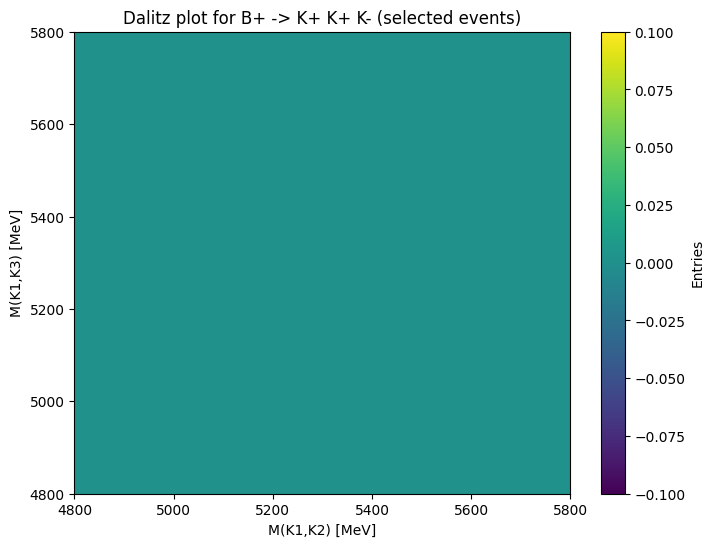

In [199]:
# function to calculate invariant mass of two particles given their momenta
def two_body_mass(PX1, PY1, PZ1, PX2, PY2, PZ2, m1=493.677, m2=493.677):
    """
    Computes invariant mass of two particles (Kaons by default) given momentum components.
    m1, m2: particle masses in MeV
    """
    Ptot1 = np.sqrt(PX1**2 + PY1**2 + PZ1**2)
    Ptot2 = np.sqrt(PX2**2 + PY2**2 + PZ2**2)

    E1 = np.sqrt(Ptot1**2 + m1**2)
    E2 = np.sqrt(Ptot2**2 + m2**2)

    PX_tot = PX1 + PX2
    PY_tot = PY1 + PY2
    PZ_tot = PZ1 + PZ2
    P_tot = np.sqrt(PX_tot**2 + PY_tot**2 + PZ_tot**2)

    return np.sqrt((E1 + E2)**2 - P_tot**2)

# compute two-body invariant masses for selected events
M12 = two_body_mass(H1_PX[selection_mask], H1_PY[selection_mask], H1_PZ[selection_mask],
                    H2_PX[selection_mask], H2_PY[selection_mask], H2_PZ[selection_mask])

M13 = two_body_mass(H1_PX[selection_mask], H1_PY[selection_mask], H1_PZ[selection_mask],
                    H3_PX[selection_mask], H3_PY[selection_mask], H3_PZ[selection_mask])

# Dalitz plot
plt.figure(figsize=(8,6))
plt.hist2d(M12, M13, bins=50, range=[[4800,5800],[4800,5800]], cmap="viridis")  # 2D histogram
plt.xlabel("M(K1,K2) [MeV]")
plt.ylabel("M(K1,K3) [MeV]")
plt.title("Dalitz plot for B+ -> K+ K+ K- (selected events)")
plt.colorbar(label="Entries")
plt.show()

We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [200]:
#Make the revised Dalitz plot here for B+ mesons

In [201]:
#Make the revised Dalitz plot here for B- mesons

In [202]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)